In [173]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import seaborn as sns
import plotly.express as px

from datetime import date
from datetime import datetime


# ANÁLISIS MUESTRA SYNTHEA

In [258]:
careplans= pd.read_csv('careplans.csv')
encounters = pd.read_csv('encounters.csv')
patients = pd.read_csv('patients.csv')


In [57]:
careplans.head(15)

,Id,START,STOP,PATIENT,ENCOUNTER,CODE,DESCRIPTION,REASONCODE,REASONDESCRIPTION
0,01612794-cb3e-02ac-1e6f-857a03b9bc69,2018-11-18,2018-12-13,d778d02c-1b71-582e-0c64-e9ce715996fc,f549ca01-9e59-e01c-0b2d-c583240c3ab1,225358003,Wound care (regime/therapy),284549007.0,Laceration of hand (disorder)
1,7ca9b0a8-2941-8c67-0778-0f132ea1a29e,2022-10-06,2023-02-02,d778d02c-1b71-582e-0c64-e9ce715996fc,aa60e9ca-6271-8103-97ad-052099369212,53950000,Respiratory therapy (procedure),NaN,NaN
2,2f17bca4-8478-8a83-b2bd-33a2d53485ce,2024-03-08,2024-04-19,958cbaed-4a32-40ff-f2ee-d55edc4f7611,e839b319-4afe-187b-219c-374d7529e79b,47387005,Head injury rehabilitation (regime/therapy),62564004.0,Concussion with loss of consciousness (disorder)
3,ae9b05d7-b88b-0a25-5f98-bcb2101baea9,2024-09-19,NaN,d778d02c-1b71-582e-0c64-e9ce715996fc,0a723901-5534-ddd3-dfd3-4bee300feb41,134435003,Routine antenatal care (regime/therapy),NaN,NaN
4,c6e88795-3d78-21a4-3ffa-12bbf59e7ae9,2014-03-25,NaN,ff3708b4-748c-ae52-2430-bc60dd9fb5dd,dbe4c0db-e925-25a1-d666-1a4b962aa43b,276239002,Therapy (regime/therapy),NaN,NaN
5,bbfb19d2-6b9c-a15a-0cda-55c0a6af5334,2016-10-18,2016-11-24,ff3708b4-748c-ae52-2430-bc60dd9fb5dd,e715b323-f531-b9bc-c478-df8fa32e883c,53950000,Respiratory therapy (procedure),NaN,NaN
6,5c0e3fbd-f4cc-6707-c453-399f4ac4c9f8,2016-11-03,2017-06-08,ff3708b4-748c-ae52-2430-bc60dd9fb5dd,4a5e541d-40b7-aa51-c17d-7f87ddc388a7,134435003,Routine antenatal care (regime/therapy),NaN,NaN
7,b82e700b-53aa-2e7a-4e54-f0b842c457b8,2020-04-05,2020-04-05,ff3708b4-748c-ae52-2430-bc60dd9fb5dd,b84f6900-c5a6-86fc-4221-6e7543bddaf2,736376001,Infectious disease care plan (record artifact),NaN,NaN
8,fb4c24bd-0872-83d7-b077-daea32d812c2,2020-04-05,2020-04-26,ff3708b4-748c-ae52-2430-bc60dd9fb5dd,b84f6900-c5a6-86fc-4221-6e7543bddaf2,736376001,Infectious disease care plan (record artifact),NaN,NaN
9,1f0b56c3-6587-b490-e0f5-1b0faabc9ed1,2024-08-15,NaN,ff3708b4-748c-ae52-2430-bc60dd9fb5dd,66fb3887-fe6d-98fd-c2c4-4c4b0e882928,134435003,Routine antenatal care (regime/therapy),NaN,NaN


In [64]:
encounters

,Id,START,STOP,PATIENT,ORGANIZATION,PROVIDER,PAYER,ENCOUNTERCLASS,CODE,DESCRIPTION,BASE_ENCOUNTER_COST,TOTAL_CLAIM_COST,PAYER_COVERAGE,REASONCODE,REASONDESCRIPTION
0,9c7664c0-33a3-6778-7845-7b08030a230c,2014-10-27T23:58:08Z,2014-10-28T00:13:08Z,958cbaed-4a32-40ff-f2ee-d55edc4f7611,d6c165ec-d9ca-35a5-9bc8-2061cbfb83a2,b9c0c3c3-14b8-3b3d-8934-5b89b2b6475b,26aab0cd-6aba-3e1b-ac5b-05c8867e762c,wellness,410620009,Well child visit (procedure),136.80,1186.78,0.00,NaN,NaN
1,75f6d06e-01e4-999f-656e-a4def079a8f6,2015-11-02T23:58:08Z,2015-11-03T00:17:06Z,958cbaed-4a32-40ff-f2ee-d55edc4f7611,d6c165ec-d9ca-35a5-9bc8-2061cbfb83a2,b9c0c3c3-14b8-3b3d-8934-5b89b2b6475b,26aab0cd-6aba-3e1b-ac5b-05c8867e762c,wellness,410620009,Well child visit (procedure),136.80,840.20,0.00,NaN,NaN
2,3682fee4-9f43-f8ae-bc5c-8a0b8b42528f,2014-12-18T14:59:14Z,2014-12-18T15:14:14Z,d778d02c-1b71-582e-0c64-e9ce715996fc,5fa5e611-be3d-3ebb-8f71-124325f6005f,236e8b0e-dba1-31a5-a5ac-f8b4dff4ecc6,0133f751-9229-3cfd-815f-b6d4979bdd6a,wellness,410620009,Well child visit (procedure),136.80,272.80,0.00,NaN,NaN
3,c77234be-e24b-5ebf-0e7a-0c835da53642,2015-05-01T04:59:14Z,2015-05-01T05:14:14Z,d778d02c-1b71-582e-0c64-e9ce715996fc,9d989fcf-4ad9-3972-ada3-f275d967781e,dc678fc2-279d-3be8-be3f-b28dc4e317fb,0133f751-9229-3cfd-815f-b6d4979bdd6a,ambulatory,185345009,Encounter for symptom (procedure),85.55,85.55,0.00,195662009.0,Acute viral pharyngitis (disorder)
4,b22ac215-c066-f45c-8201-673d1d33f67b,2016-11-07T23:58:08Z,2016-11-08T00:13:08Z,958cbaed-4a32-40ff-f2ee-d55edc4f7611,d6c165ec-d9ca-35a5-9bc8-2061cbfb83a2,b9c0c3c3-14b8-3b3d-8934-5b89b2b6475b,26aab0cd-6aba-3e1b-ac5b-05c8867e762c,wellness,410620009,Well child visit (procedure),136.80,1305.43,0.00,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32745,4c2c13fc-389c-5305-dfe8-84cb7ff2f300,2022-12-26T00:29:08Z,2022-12-26T01:02:33Z,5c25efe7-fc0a-3afa-5577-72c3f5cfc7f0,e5b9db6a-8dd8-3622-b9ce-3dc593e111d1,bee22fdb-0ccc-32aa-80d3-f9e677dc8d4f,df166300-5a78-3502-a46a-832842197811,wellness,162673000,General examination of patient (procedure),136.80,853.36,753.36,NaN,NaN
32746,9827a5ac-0451-516d-031b-eab536d839d2,2023-09-25T05:29:08Z,2023-09-25T05:44:08Z,5c25efe7-fc0a-3afa-5577-72c3f5cfc7f0,c7542447-e06e-32cb-b6db-243c23a0dbc2,a8287324-f8d6-31e1-beae-004b795fa507,df166300-5a78-3502-a46a-832842197811,ambulatory,185345009,Encounter for symptom (procedure),85.55,85.55,35.55,75498004.0,Acute bacterial sinusitis (disorder)
32747,19ab31ad-8140-02fb-d3d9-04ef7225ef99,2023-10-28T05:29:08Z,2023-10-28T05:44:08Z,5c25efe7-fc0a-3afa-5577-72c3f5cfc7f0,c7542447-e06e-32cb-b6db-243c23a0dbc2,a8287324-f8d6-31e1-beae-004b795fa507,df166300-5a78-3502-a46a-832842197811,ambulatory,185345009,Encounter for symptom (procedure),85.55,92.93,42.93,75498004.0,Acute bacterial sinusitis (disorder)
32748,b8bdd2bf-b6e0-85d8-2f13-fac2c1bbcdcf,2024-01-01T00:29:08Z,2024-01-01T01:14:49Z,5c25efe7-fc0a-3afa-5577-72c3f5cfc7f0,e5b9db6a-8dd8-3622-b9ce-3dc593e111d1,bee22fdb-0ccc-32aa-80d3-f9e677dc8d4f,df166300-5a78-3502-a46a-832842197811,wellness,162673000,General examination of patient (procedure),136.80,1632.30,1532.30,NaN,NaN


In [68]:
patients

,Id,BIRTHDATE,DEATHDATE,SSN,DRIVERS,PASSPORT,PREFIX,FIRST,MIDDLE,LAST,...,CITY,STATE,COUNTY,FIPS,ZIP,LAT,LON,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE,INCOME
0,958cbaed-4a32-40ff-f2ee-d55edc4f7611,2003-10-13,NaN,999-46-5780,S99985773,X43751887X,Ms.,Sol312,Ciara810,Baumbach677,...,Tyngsborough,Massachusetts,Middlesex County,NaN,0,42.678887,-71.466652,83748.67,8386.12,847165
1,d778d02c-1b71-582e-0c64-e9ce715996fc,2004-12-09,NaN,999-44-8153,S99922963,X17785689X,Ms.,Irma773,Terresa418,Shields502,...,Barnstable,Massachusetts,Barnstable County,25001.0,2648,41.712246,-70.451110,80934.70,70863.00,62412
2,ff3708b4-748c-ae52-2430-bc60dd9fb5dd,1991-09-05,NaN,999-31-9506,S99963368,X48163920X,Mrs.,Rocio28,Ángela136,Bermúdez789,...,Chicopee,Massachusetts,Hampden County,25013.0,1020,42.175006,-72.570417,10853.87,707739.51,1348
3,8cc46582-8727-0024-6010-c5e7e2943578,2000-07-25,NaN,999-55-8680,S99950926,X19763814X,Ms.,Lelah386,Crystal2,Leannon79,...,Worcester,Massachusetts,Worcester County,25027.0,1605,42.192066,-71.751869,122151.80,144375.81,95771
4,6da671b7-6462-2ced-5b86-5b0fced4308b,1974-02-04,NaN,999-31-4155,S99970004,X2187110X,Mrs.,Olympia319,Pamula578,Huels583,...,Revere,Massachusetts,Suffolk County,25025.0,2151,42.461726,-71.000002,186763.75,853299.76,26068
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
359,3eae3f10-5a0a-06ed-0394-ce31eee9dcad,1968-11-22,1998-04-10,999-29-1885,S99917657,X24168209X,Ms.,Glenna97,Sherry479,Friesen796,...,Barnstable,Massachusetts,Barnstable County,25001.0,2630,41.724517,-70.300414,11151.16,1108113.17,22800
360,4c5b8cb6-f5e5-8610-5200-2d85076188b7,1971-05-27,2016-07-31,999-91-8201,S99932905,X74962575X,Mrs.,Freeda113,Charlyn749,Larson43,...,Barnstable,Massachusetts,Barnstable County,25001.0,2601,41.621519,-70.306881,579292.23,314816.37,52934
361,e00f0d3b-e390-b39c-d2e5-8c2db6b7feba,1967-12-26,1993-08-29,999-33-1496,S99997260,X87678265X,Ms.,Senaida415,Ying817,Kiehn525,...,Boston,Massachusetts,Suffolk County,25025.0,2129,42.384591,-71.117556,7950.16,519376.83,7445
362,c98c8053-9db4-940c-60f8-afc6f27d26a1,1966-10-20,1999-02-04,999-40-1502,S99988166,X44490311X,Ms.,Ivory697,Alise864,Stracke611,...,Longmeadow,Massachusetts,Hampden County,25013.0,1106,42.074314,-72.578348,156624.98,266749.55,336199


# OBJETIVOS DEL CUADERNO

De los datos sintéticos obtenidos con el software opensource de <a href="https://mitre.github.io/fhir-for-research/modules/synthea-overview#generic-modules">synthea</a>, vamos a obtener tres datasets, uno dedicado para cada algoritmo y que sirvan de modelo para replicar y extender como datos del wearable. 
<p>Los datasets a crear son:</p>
<ul>
    <li><code>vitalSignsEncounter</code>: con datos sobre IMC, presión arterial sistólica y diastólica, temperatura corporal, ritmo cardíaco y glucosa en sangre. Cada usuario está identificado con un único ID (userID), también se registra la fecha de la medición y la edad del paciente.</li>
    <li><code>glucoseAssessment</code>: con datos sobre la glucosa en sangre, niveles de hemoglobina en sangre, HDL y BMI. También se registra el userID, la fecha de la medida y la edad de la paciente.</li>
    <li><code>hypertensionAssessment</code>: con datos de niveles de proteínas en la orina,IMC, presión arterial sistólica y diastólica, niveles de hemglobina, edad de la paciente y semana de embarazo. </li>
</ul>

Para esta tarea, primero en el dataset <code>careplan</code>, filtramos a las pacientes para quedarnos sólo con aquellas que estén siendo tratadas como un embarazo normal, ya que las ya diagnosticadas servirán para validar la precisión del sistema. Tras esto, queremos quedarnos con las que más información tengan registradas, es decir, las que hayan ido al menos una vez al trimestre a la consulta, que lo hacemos por medio del dataset <code>encounters</code>, y finalmente filtramos el dataset <code>observations</code> para quedarnos con estas pacientes. 

La fecha de observación se fija desde 01/01/2024 hasta 01/10/2024. 

## 1. FILTRO DE PACIENTES SEGÚN TRATAMIENTO Y FECHA DE OBSERVACIÓN

El código de tratamiento que estamos buscando es: 134435003 - Routine Antenatal Care

In [264]:
careplans['START'] = pd.to_datetime(careplans['START'])
careplans['STOP'] = pd.to_datetime(careplans['STOP'])

In [266]:
nullDates = careplans['START'].isnull().sum()
print(f"null values en la columna start {nullDates}")

null values en la columna start 0


In [268]:
antenatalCarePlan = careplans.query("CODE == 134435003")

In [270]:
antenatalCarePlan.info()

<class 'pandas.core.frame.DataFrame'>
Index: 755 entries, 3 to 1816
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Id                 755 non-null    object        
 1   START              755 non-null    datetime64[ns]
 2   STOP               425 non-null    datetime64[ns]
 3   PATIENT            755 non-null    object        
 4   ENCOUNTER          755 non-null    object        
 5   CODE               755 non-null    int64         
 6   DESCRIPTION        755 non-null    object        
 7   REASONCODE         0 non-null      float64       
 8   REASONDESCRIPTION  0 non-null      object        
dtypes: datetime64[ns](2), float64(1), int64(1), object(5)
memory usage: 59.0+ KB


In [272]:
antenatalCarePlan['START'] = antenatalCarePlan[antenatalCarePlan['START'] >= '2024-01-01']['START'].reset_index(drop=True)
antenatalCarePlan.head(15)

C:\Users\virginia.anton\AppData\Local\Temp\ipykernel_31524\2338180506.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,Id,START,STOP,PATIENT,ENCOUNTER,CODE,DESCRIPTION,REASONCODE,REASONDESCRIPTION
3,ae9b05d7-b88b-0a25-5f98-bcb2101baea9,2024-08-19,NaT,d778d02c-1b71-582e-0c64-e9ce715996fc,0a723901-5534-ddd3-dfd3-4bee300feb41,134435003,Routine antenatal care (regime/therapy),NaN,NaN
6,5c0e3fbd-f4cc-6707-c453-399f4ac4c9f8,2024-12-12,2017-06-08,ff3708b4-748c-ae52-2430-bc60dd9fb5dd,4a5e541d-40b7-aa51-c17d-7f87ddc388a7,134435003,Routine antenatal care (regime/therapy),NaN,NaN
9,1f0b56c3-6587-b490-e0f5-1b0faabc9ed1,2024-12-08,NaT,ff3708b4-748c-ae52-2430-bc60dd9fb5dd,66fb3887-fe6d-98fd-c2c4-4c4b0e882928,134435003,Routine antenatal care (regime/therapy),NaN,NaN
11,244d72d3-69a0-85b5-ffce-bc2ed42d0a65,2024-10-14,2021-04-20,8cc46582-8727-0024-6010-c5e7e2943578,2a07b3a5-0e66-01bb-058d-f8502e8eaada,134435003,Routine antenatal care (regime/therapy),NaN,NaN
13,591916e7-0d89-6850-2e85-6912804158d1,2024-09-21,NaT,8cc46582-8727-0024-6010-c5e7e2943578,20d0a9bd-0efd-263a-dbdb-d8f6a13dabd3,134435003,Routine antenatal care (regime/therapy),NaN,NaN
17,f0ec5d0f-1205-b273-20c4-daeb7bf3a45e,2024-06-17,NaT,6da671b7-6462-2ced-5b86-5b0fced4308b,d256a96a-1312-c908-e11b-7f412ddc2efa,134435003,Routine antenatal care (regime/therapy),NaN,NaN
18,7309b141-7ec2-42b4-a310-2fdca6d7fa06,2024-10-26,2016-08-21,1921a3af-f53d-0a0a-9dfe-3be55779424c,4ea265ea-e1e5-c8a4-4193-4d65f5084ca0,134435003,Routine antenatal care (regime/therapy),NaN,NaN
19,5ccec3de-f099-c233-b6c8-4dab69fd5e8b,2024-07-26,2017-08-13,1921a3af-f53d-0a0a-9dfe-3be55779424c,bae493c3-4513-6cc9-c21c-d5d9c49ac13a,134435003,Routine antenatal care (regime/therapy),NaN,NaN
22,0311c7a2-0e6b-8f92-936e-e70b0d5d8097,2024-10-02,2015-01-17,4f004e54-d70e-8897-2727-5a57e1a7b9b6,50f28eda-d24f-1000-7623-b20e4c45de0a,134435003,Routine antenatal care (regime/therapy),NaN,NaN
24,4ea93d27-6e8a-a264-0463-e7fef6ec04dd,2024-09-15,2018-08-18,4f004e54-d70e-8897-2727-5a57e1a7b9b6,db0b7618-d8d8-ea04-2987-9ead5149a42a,134435003,Routine antenatal care (regime/therapy),NaN,NaN


Vamos a comprobar cuantos valores nulos hay en la columna START del df:

In [275]:
startNullCount = antenatalCarePlan['START'].isnull().sum()
print(f"Valores nulos en la columna START: {startNullCount} de {antenatalCarePlan['START'].shape[0]}")

Valores nulos en la columna START: 673 de 755


In [277]:
antenatalCarePlanFiltered = antenatalCarePlan[antenatalCarePlan['START'].notnull()]

In [279]:
antenatalCarePlanFiltered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 82 entries, 3 to 183
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Id                 82 non-null     object        
 1   START              82 non-null     datetime64[ns]
 2   STOP               42 non-null     datetime64[ns]
 3   PATIENT            82 non-null     object        
 4   ENCOUNTER          82 non-null     object        
 5   CODE               82 non-null     int64         
 6   DESCRIPTION        82 non-null     object        
 7   REASONCODE         0 non-null      float64       
 8   REASONDESCRIPTION  0 non-null      object        
dtypes: datetime64[ns](2), float64(1), int64(1), object(5)
memory usage: 6.4+ KB


In [281]:
antenatalCarePlanFiltered

,Id,START,STOP,PATIENT,ENCOUNTER,CODE,DESCRIPTION,REASONCODE,REASONDESCRIPTION
3,ae9b05d7-b88b-0a25-5f98-bcb2101baea9,2024-08-19,NaT,d778d02c-1b71-582e-0c64-e9ce715996fc,0a723901-5534-ddd3-dfd3-4bee300feb41,134435003,Routine antenatal care (regime/therapy),NaN,NaN
6,5c0e3fbd-f4cc-6707-c453-399f4ac4c9f8,2024-12-12,2017-06-08,ff3708b4-748c-ae52-2430-bc60dd9fb5dd,4a5e541d-40b7-aa51-c17d-7f87ddc388a7,134435003,Routine antenatal care (regime/therapy),NaN,NaN
9,1f0b56c3-6587-b490-e0f5-1b0faabc9ed1,2024-12-08,NaT,ff3708b4-748c-ae52-2430-bc60dd9fb5dd,66fb3887-fe6d-98fd-c2c4-4c4b0e882928,134435003,Routine antenatal care (regime/therapy),NaN,NaN
11,244d72d3-69a0-85b5-ffce-bc2ed42d0a65,2024-10-14,2021-04-20,8cc46582-8727-0024-6010-c5e7e2943578,2a07b3a5-0e66-01bb-058d-f8502e8eaada,134435003,Routine antenatal care (regime/therapy),NaN,NaN
13,591916e7-0d89-6850-2e85-6912804158d1,2024-09-21,NaT,8cc46582-8727-0024-6010-c5e7e2943578,20d0a9bd-0efd-263a-dbdb-d8f6a13dabd3,134435003,Routine antenatal care (regime/therapy),NaN,NaN
...,...,...,...,...,...,...,...,...,...
174,474f3ca0-74e7-64cc-a673-851de5a9e6c5,2024-09-09,NaT,6266756a-304d-4dee-4f2c-6b1055e8b586,fad0e6bd-cd40-3d19-67e6-46cbfaa8fe3a,134435003,Routine antenatal care (regime/therapy),NaN,NaN
176,36924061-2a51-0d3f-af09-e82c1fcdb9eb,2024-06-15,2017-06-27,bbe262a6-238d-365d-73d4-3c5eb36426b3,d4fe1d65-45d9-7577-f24e-dd1a468b1773,134435003,Routine antenatal care (regime/therapy),NaN,NaN
177,2621682c-4ef0-c9cb-c875-6b0a14528d35,2024-11-17,2019-10-08,bbe262a6-238d-365d-73d4-3c5eb36426b3,e7e8ecad-9bb4-4259-b481-8ea257916c74,134435003,Routine antenatal care (regime/therapy),NaN,NaN
178,527705e4-bb5b-b9ac-edd5-de8e47830d1a,2024-10-17,NaT,bbe262a6-238d-365d-73d4-3c5eb36426b3,0283bea5-248d-b588-cf41-c505caad4f1f,134435003,Routine antenatal care (regime/therapy),NaN,NaN


De aquí sacamos los ID de las pacientes y la fecha de start para mirar cuántas veces son atendidas para este tratamiento a lo largo de la gestacion

In [284]:
encounters['antenatal_careplan'] = encounters['PATIENT'].isin(antenatalCarePlanFiltered['PATIENT'])

In [286]:
encounters.query("antenatal_careplan == True")

,Id,START,STOP,PATIENT,ORGANIZATION,PROVIDER,PAYER,ENCOUNTERCLASS,CODE,DESCRIPTION,BASE_ENCOUNTER_COST,TOTAL_CLAIM_COST,PAYER_COVERAGE,REASONCODE,REASONDESCRIPTION,antenatal_careplan
2,3682fee4-9f43-f8ae-bc5c-8a0b8b42528f,2014-12-18T14:59:14Z,2014-12-18T15:14:14Z,d778d02c-1b71-582e-0c64-e9ce715996fc,5fa5e611-be3d-3ebb-8f71-124325f6005f,236e8b0e-dba1-31a5-a5ac-f8b4dff4ecc6,0133f751-9229-3cfd-815f-b6d4979bdd6a,wellness,410620009,Well child visit (procedure),136.80,272.80,0.00,NaN,NaN,True
3,c77234be-e24b-5ebf-0e7a-0c835da53642,2015-05-01T04:59:14Z,2015-05-01T05:14:14Z,d778d02c-1b71-582e-0c64-e9ce715996fc,9d989fcf-4ad9-3972-ada3-f275d967781e,dc678fc2-279d-3be8-be3f-b28dc4e317fb,0133f751-9229-3cfd-815f-b6d4979bdd6a,ambulatory,185345009,Encounter for symptom (procedure),85.55,85.55,0.00,195662009.0,Acute viral pharyngitis (disorder),True
5,dec60578-6d45-e7a1-ccbf-5c8a031f93c7,2015-09-13T16:59:14Z,2015-09-13T17:14:14Z,d778d02c-1b71-582e-0c64-e9ce715996fc,9d989fcf-4ad9-3972-ada3-f275d967781e,dc678fc2-279d-3be8-be3f-b28dc4e317fb,0133f751-9229-3cfd-815f-b6d4979bdd6a,ambulatory,185345009,Encounter for symptom (procedure),85.55,85.55,0.00,444814009.0,Viral sinusitis (disorder),True
6,99b291c0-18a3-afd1-f002-cb3bf4367b4e,2015-12-24T14:59:14Z,2015-12-24T15:14:14Z,d778d02c-1b71-582e-0c64-e9ce715996fc,5fa5e611-be3d-3ebb-8f71-124325f6005f,236e8b0e-dba1-31a5-a5ac-f8b4dff4ecc6,0133f751-9229-3cfd-815f-b6d4979bdd6a,wellness,410620009,Well child visit (procedure),136.80,1467.35,0.00,NaN,NaN,True
7,00999c4a-7760-e0f8-faca-533d26ef6687,2015-12-31T14:59:14Z,2015-12-31T23:03:11Z,d778d02c-1b71-582e-0c64-e9ce715996fc,9d989fcf-4ad9-3972-ada3-f275d967781e,dc678fc2-279d-3be8-be3f-b28dc4e317fb,0133f751-9229-3cfd-815f-b6d4979bdd6a,ambulatory,185349003,Encounter for check up (procedure),85.55,4830.95,200.54,66383009.0,Gingivitis (disorder),True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2983,8c60c42f-4287-200c-82c0-ab5e5354bb46,2024-09-10T16:04:04Z,2024-09-10T16:19:04Z,0cbe423a-9510-4d99-18e4-fb00ad5d7f50,901c2d40-1ca3-3879-9a20-c663b8adc0a9,68cb0a13-a299-3add-89bf-586ffb3cb473,e03e23c9-4df1-3eb6-a62d-f70f02301496,ambulatory,424619006,Prenatal visit (regime/therapy),142.58,8262.20,0.00,72892002.0,Normal pregnancy (finding),True
2984,e9b097f3-bb22-918e-acbb-f543ab5ebce0,2024-10-08T16:04:04Z,2024-10-08T16:19:04Z,0cbe423a-9510-4d99-18e4-fb00ad5d7f50,901c2d40-1ca3-3879-9a20-c663b8adc0a9,68cb0a13-a299-3add-89bf-586ffb3cb473,e03e23c9-4df1-3eb6-a62d-f70f02301496,ambulatory,424619006,Prenatal visit (regime/therapy),142.58,14977.36,0.00,72892002.0,Normal pregnancy (finding),True
2985,8c8c8c65-a7ab-afa9-9420-204a26a8cdc1,2024-11-05T16:04:04Z,2024-11-05T16:19:04Z,0cbe423a-9510-4d99-18e4-fb00ad5d7f50,901c2d40-1ca3-3879-9a20-c663b8adc0a9,68cb0a13-a299-3add-89bf-586ffb3cb473,e03e23c9-4df1-3eb6-a62d-f70f02301496,ambulatory,424619006,Prenatal visit (regime/therapy),142.58,11451.02,0.00,72892002.0,Normal pregnancy (finding),True
2986,df1308bc-3f0a-5697-c0be-35143dedbde6,2024-12-03T16:04:04Z,2024-12-03T16:19:04Z,0cbe423a-9510-4d99-18e4-fb00ad5d7f50,901c2d40-1ca3-3879-9a20-c663b8adc0a9,68cb0a13-a299-3add-89bf-586ffb3cb473,e03e23c9-4df1-3eb6-a62d-f70f02301496,ambulatory,424619006,Prenatal visit (regime/therapy),142.58,9005.68,0.00,72892002.0,Normal pregnancy (finding),True


Filtramos para que nos salgan las consultas a partir del 01/01/2024

In [289]:
#CONVERTIMOS A DATETIME LAS COLUMNAS START Y STOP
encounters['START'] = pd.to_datetime(encounters['START'])
encounters['STOP'] = pd.to_datetime(encounters['STOP'])

#Filtramos las filas donde START sea a partir del 01/01/2024
encountersFiltered = encounters[encounters['START'] >= '2024-01-01'].reset_index(drop=True)

In [291]:
encountersFiltered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2177 entries, 0 to 2176
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype              
---  ------               --------------  -----              
 0   Id                   2177 non-null   object             
 1   START                2177 non-null   datetime64[ns, UTC]
 2   STOP                 2177 non-null   datetime64[ns, UTC]
 3   PATIENT              2177 non-null   object             
 4   ORGANIZATION         2177 non-null   object             
 5   PROVIDER             2177 non-null   object             
 6   PAYER                2177 non-null   object             
 7   ENCOUNTERCLASS       2177 non-null   object             
 8   CODE                 2177 non-null   int64              
 9   DESCRIPTION          2177 non-null   object             
 10  BASE_ENCOUNTER_COST  2177 non-null   float64            
 11  TOTAL_CLAIM_COST     2177 non-null   float64            
 12  PAYER_COVERAGE      

In [293]:
encountersFiltered

,Id,START,STOP,PATIENT,ORGANIZATION,PROVIDER,PAYER,ENCOUNTERCLASS,CODE,DESCRIPTION,BASE_ENCOUNTER_COST,TOTAL_CLAIM_COST,PAYER_COVERAGE,REASONCODE,REASONDESCRIPTION,antenatal_careplan
0,b485a224-78c9-3e6f-d18d-bf93764cc350,2024-02-08 14:59:14+00:00,2024-02-08 15:53:58+00:00,d778d02c-1b71-582e-0c64-e9ce715996fc,5fa5e611-be3d-3ebb-8f71-124325f6005f,236e8b0e-dba1-31a5-a5ac-f8b4dff4ecc6,8fa6c185-e44e-3e34-8bd8-39be8694f4ce,wellness,162673000,General examination of patient (procedure),136.80,704.20,0.00,NaN,NaN,True
1,dcedf098-d307-b5bc-0609-7acf86c52b02,2024-02-22 14:59:14+00:00,2024-02-22 18:40:30+00:00,d778d02c-1b71-582e-0c64-e9ce715996fc,9d989fcf-4ad9-3972-ada3-f275d967781e,dc678fc2-279d-3be8-be3f-b28dc4e317fb,8fa6c185-e44e-3e34-8bd8-39be8694f4ce,ambulatory,185349003,Encounter for check up (procedure),85.55,3105.35,0.00,66383009.0,Gingivitis (disorder),True
2,0a723901-5534-ddd3-dfd3-4bee300feb41,2024-09-19 14:59:14+00:00,2024-09-19 15:14:14+00:00,d778d02c-1b71-582e-0c64-e9ce715996fc,9d989fcf-4ad9-3972-ada3-f275d967781e,dc678fc2-279d-3be8-be3f-b28dc4e317fb,8fa6c185-e44e-3e34-8bd8-39be8694f4ce,ambulatory,424441002,Prenatal initial visit (regime/therapy),142.58,55053.32,38144.95,72892002.0,Normal pregnancy (finding),True
3,e839b319-4afe-187b-219c-374d7529e79b,2024-03-08 00:34:47+00:00,2024-03-08 01:34:47+00:00,958cbaed-4a32-40ff-f2ee-d55edc4f7611,f0e3e152-0b08-3819-b962-b043f63f6dc1,a8b071aa-59c6-3d54-b799-c28a697ed75f,26aab0cd-6aba-3e1b-ac5b-05c8867e762c,emergency,50849002,Emergency room admission (procedure),146.18,146.18,0.00,110030002.0,Concussion injury of brain (disorder),False
4,acae6c36-ec9e-d1f6-c95f-0d2d22580597,2024-04-19 00:34:47+00:00,2024-04-19 00:49:47+00:00,958cbaed-4a32-40ff-f2ee-d55edc4f7611,06cc2462-430f-3322-9c87-7e971125f510,e90cb995-6e59-31e7-9e03-512081d49303,26aab0cd-6aba-3e1b-ac5b-05c8867e762c,ambulatory,185349003,Encounter for check up (procedure),85.55,85.55,0.00,62564004.0,Concussion with loss of consciousness (disorder),False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2172,45048f97-3e00-518f-fa52-b0f6387327bf,2024-11-04 15:58:38+00:00,2024-11-04 16:13:38+00:00,d722b722-99ef-37a7-f021-46a3afdca6d1,352f2e3b-0708-3eb4-9f7e-e73a685bf379,bf37e7f1-f7f7-320b-914c-b35197ad78f6,e03e23c9-4df1-3eb6-a62d-f70f02301496,ambulatory,424441002,Prenatal initial visit (regime/therapy),142.58,45027.70,0.00,72892002.0,Normal pregnancy (finding),False
2173,111b656b-cc8e-cb98-d5a4-fd0a06cb3932,2024-11-28 01:27:26+00:00,2024-11-28 10:27:26+00:00,d722b722-99ef-37a7-f021-46a3afdca6d1,7f32dd7d-5c35-3ddb-839b-8fbbb930d412,c8e8633b-4765-3f9d-923e-557e5001e34c,e03e23c9-4df1-3eb6-a62d-f70f02301496,emergency,50849002,Emergency room admission (procedure),146.18,146.18,0.00,55680006.0,Drug overdose,False
2174,11a0ddb6-0c7a-92c5-50a0-a93d6de9a42f,2024-12-02 15:58:38+00:00,2024-12-02 16:13:38+00:00,d722b722-99ef-37a7-f021-46a3afdca6d1,352f2e3b-0708-3eb4-9f7e-e73a685bf379,bf37e7f1-f7f7-320b-914c-b35197ad78f6,e03e23c9-4df1-3eb6-a62d-f70f02301496,ambulatory,424619006,Prenatal visit (regime/therapy),142.58,19098.88,0.00,72892002.0,Normal pregnancy (finding),False
2175,b8bdd2bf-b6e0-85d8-2f13-fac2c1bbcdcf,2024-01-01 00:29:08+00:00,2024-01-01 01:14:49+00:00,5c25efe7-fc0a-3afa-5577-72c3f5cfc7f0,e5b9db6a-8dd8-3622-b9ce-3dc593e111d1,bee22fdb-0ccc-32aa-80d3-f9e677dc8d4f,df166300-5a78-3502-a46a-832842197811,wellness,162673000,General examination of patient (procedure),136.80,1632.30,1532.30,NaN,NaN,False


Nos hemos quedado con las pacientes embarazadas en la fecha seleccionada, pero sólo estamos interesados en la información de las visitas prenatales o las obstétricas de emergencia. Así vamos a quedarnos con estas entradas. 

Vamos a ver cuántas veces aparece cada paciente. 

In [297]:
encountersFiltered.query("CODE == 424619006 or CODE == 183460006")

,Id,START,STOP,PATIENT,ORGANIZATION,PROVIDER,PAYER,ENCOUNTERCLASS,CODE,DESCRIPTION,BASE_ENCOUNTER_COST,TOTAL_CLAIM_COST,PAYER_COVERAGE,REASONCODE,REASONDESCRIPTION,antenatal_careplan
7,eec0010f-e79c-f8ce-0f40-4bfda83aa93c,2024-10-17 14:59:14+00:00,2024-10-17 15:14:14+00:00,d778d02c-1b71-582e-0c64-e9ce715996fc,9d989fcf-4ad9-3972-ada3-f275d967781e,dc678fc2-279d-3be8-be3f-b28dc4e317fb,8fa6c185-e44e-3e34-8bd8-39be8694f4ce,ambulatory,424619006,Prenatal visit (regime/therapy),142.58,10091.82,10091.82,72892002.0,Normal pregnancy (finding),True
8,e7ed1b59-5a3a-21db-2c6a-694304854ba4,2024-11-14 14:59:14+00:00,2024-11-14 15:14:14+00:00,d778d02c-1b71-582e-0c64-e9ce715996fc,9d989fcf-4ad9-3972-ada3-f275d967781e,dc678fc2-279d-3be8-be3f-b28dc4e317fb,8fa6c185-e44e-3e34-8bd8-39be8694f4ce,ambulatory,424619006,Prenatal visit (regime/therapy),142.58,8548.56,8548.56,72892002.0,Normal pregnancy (finding),True
9,0ea068c2-5f08-754a-76ae-08078f1a1854,2024-12-12 14:59:14+00:00,2024-12-12 15:14:14+00:00,d778d02c-1b71-582e-0c64-e9ce715996fc,9d989fcf-4ad9-3972-ada3-f275d967781e,dc678fc2-279d-3be8-be3f-b28dc4e317fb,8fa6c185-e44e-3e34-8bd8-39be8694f4ce,ambulatory,424619006,Prenatal visit (regime/therapy),142.58,11451.02,4865.71,72892002.0,Normal pregnancy (finding),True
14,3006dcd8-f7d3-fede-4c4e-7b46c0c860b1,2024-09-12 18:23:00+00:00,2024-09-12 18:38:00+00:00,ff3708b4-748c-ae52-2430-bc60dd9fb5dd,0d9b0d22-585e-3fd8-ab02-26b5be7915d1,22f5aefd-a242-3292-89ee-00b423462eff,df166300-5a78-3502-a46a-832842197811,ambulatory,424619006,Prenatal visit (regime/therapy),142.58,10870.23,10720.23,72892002.0,Normal pregnancy (finding),True
15,ae8a274f-8609-4777-1af1-dd3e53caa05c,2024-10-10 18:23:00+00:00,2024-10-10 18:38:00+00:00,ff3708b4-748c-ae52-2430-bc60dd9fb5dd,0d9b0d22-585e-3fd8-ab02-26b5be7915d1,22f5aefd-a242-3292-89ee-00b423462eff,df166300-5a78-3502-a46a-832842197811,ambulatory,424619006,Prenatal visit (regime/therapy),142.58,13595.53,13545.53,72892002.0,Normal pregnancy (finding),True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2162,091b5987-73d5-96ed-bbb1-6fedffdcba86,2024-11-30 15:33:38+00:00,2024-11-30 15:48:38+00:00,faa32210-cefe-9df6-bac3-ba195e4d7247,ab16be57-62ea-39a5-8f7a-ee1285cf6934,c02068e9-4fd9-3809-bc32-6ff19ff27bcb,26aab0cd-6aba-3e1b-ac5b-05c8867e762c,ambulatory,424619006,Prenatal visit (regime/therapy),142.58,18236.08,18236.08,72892002.0,Normal pregnancy (finding),False
2166,b79ad78e-e12b-6e66-000b-ae9a3f1ed61f,2024-10-23 04:31:07+00:00,2024-10-23 04:46:07+00:00,3a4f7ecf-c03d-6d9d-af23-8ad9de7b7ca2,a5577e5c-b886-37a0-8eee-8ff6feb7ea6b,223e3e83-58f6-3b2a-8283-b2ad1c289991,a735bf55-83e9-331a-899d-a82a60b9f60c,ambulatory,424619006,Prenatal visit (regime/therapy),142.58,13068.94,10455.15,72892002.0,Normal pregnancy (finding),False
2168,ea8de101-a076-d03f-6413-adf5a092a254,2024-11-20 04:31:07+00:00,2024-11-20 04:46:07+00:00,3a4f7ecf-c03d-6d9d-af23-8ad9de7b7ca2,a5577e5c-b886-37a0-8eee-8ff6feb7ea6b,223e3e83-58f6-3b2a-8283-b2ad1c289991,a735bf55-83e9-331a-899d-a82a60b9f60c,ambulatory,424619006,Prenatal visit (regime/therapy),142.58,14605.43,11684.34,72892002.0,Normal pregnancy (finding),False
2169,79753b51-ad52-cb4c-1b6a-3a24a74308d7,2024-12-18 04:31:07+00:00,2024-12-18 04:46:07+00:00,3a4f7ecf-c03d-6d9d-af23-8ad9de7b7ca2,a5577e5c-b886-37a0-8eee-8ff6feb7ea6b,223e3e83-58f6-3b2a-8283-b2ad1c289991,a735bf55-83e9-331a-899d-a82a60b9f60c,ambulatory,424619006,Prenatal visit (regime/therapy),142.58,7484.47,5987.57,72892002.0,Normal pregnancy (finding),False


### Distribución visitas mensuales

C:\Users\virginia.anton\AppData\Local\Temp\ipykernel_31524\1790469152.py:2: UserWarning:

Converting to PeriodArray/Index representation will drop timezone information.



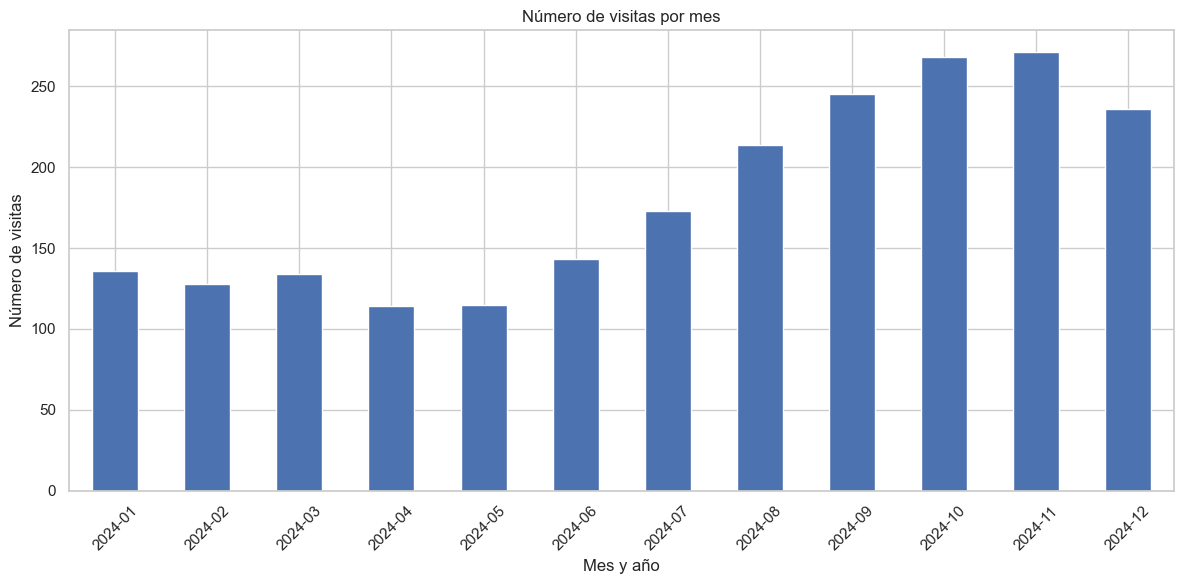

In [300]:
#creamos una columna auxiliar por mes y año:
encountersFiltered['Month_Year'] = encountersFiltered['START'].dt.to_period('M')

#número de visitas por mes:
monthly_visits = encountersFiltered['Month_Year'].value_counts().sort_index()

plt.figure(figsize=(12,6))
monthly_visits.plot(kind='bar')
plt.title('Número de visitas por mes')
plt.xlabel('Mes y año')
plt.ylabel('Número de visitas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Tenemos bastantes visitas como para hacer seguimiento, vamos a mirar cuántas tiene cada usuario

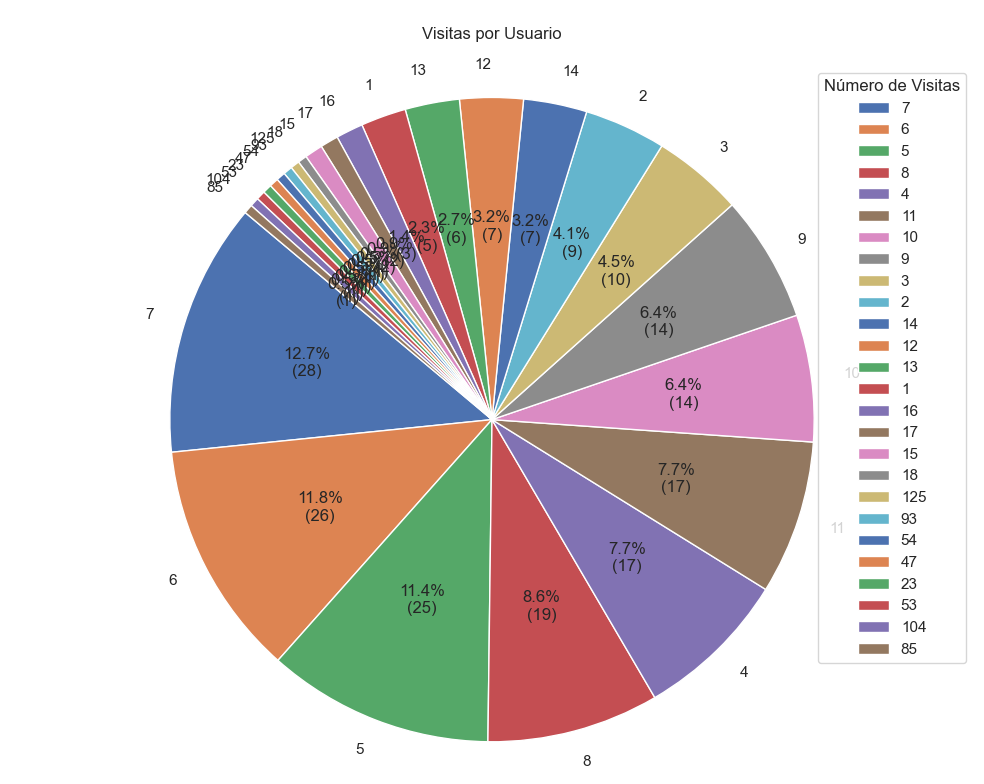

In [303]:
max_visits_user = encountersFiltered.groupby('PATIENT')['Id'].count()

#cantidad de usuarios por cada máximo de visitas
user_counts = max_visits_user.value_counts()
user_percentages = (user_counts/user_counts.sum())*100

plt.figure(figsize=(10,8))
plt.pie(user_counts, labels=user_counts.index, autopct=lambda p: f'{p:.1f}%\n({p*user_counts.sum()/100:.0f})', startangle=140)
plt.title('\nVisitas por Usuario\n')
plt.axis('equal')
plt.legend(title='Número de Visitas', loc='upper right')
plt.tight_layout()
plt.show()

En general, las pacientes acuden más de tres veces, así, podemos descartar las que acuden menos de 3 veces, ya que apenas hay información sobre su estado. 

In [306]:
patients_to_keep = max_visits_user[max_visits_user >= 3].index
encountersFiltered = encountersFiltered[encountersFiltered['PATIENT'].isin(patients_to_keep)].reset_index(drop=True)

In [308]:
encountersFiltered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2154 entries, 0 to 2153
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype              
---  ------               --------------  -----              
 0   Id                   2154 non-null   object             
 1   START                2154 non-null   datetime64[ns, UTC]
 2   STOP                 2154 non-null   datetime64[ns, UTC]
 3   PATIENT              2154 non-null   object             
 4   ORGANIZATION         2154 non-null   object             
 5   PROVIDER             2154 non-null   object             
 6   PAYER                2154 non-null   object             
 7   ENCOUNTERCLASS       2154 non-null   object             
 8   CODE                 2154 non-null   int64              
 9   DESCRIPTION          2154 non-null   object             
 10  BASE_ENCOUNTER_COST  2154 non-null   float64            
 11  TOTAL_CLAIM_COST     2154 non-null   float64            
 12  PAYER_COVERAGE      

Vemos si falta algun identificador de usuario en la fila PATIENT:

In [311]:
encountersFiltered['PATIENT'].isnull().sum()

0

# EDA DE LOS PACIENTES

In [314]:
patients = patients[patients['Id'].isin(encountersFiltered['PATIENT'])]

In [316]:
patients.info()

<class 'pandas.core.frame.DataFrame'>
Index: 206 entries, 0 to 353
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Id                   206 non-null    object 
 1   BIRTHDATE            206 non-null    object 
 2   DEATHDATE            0 non-null      object 
 3   SSN                  206 non-null    object 
 4   DRIVERS              206 non-null    object 
 5   PASSPORT             182 non-null    object 
 6   PREFIX               197 non-null    object 
 7   FIRST                206 non-null    object 
 8   MIDDLE               164 non-null    object 
 9   LAST                 206 non-null    object 
 10  SUFFIX               2 non-null      object 
 11  MAIDEN               122 non-null    object 
 12  MARITAL              149 non-null    object 
 13  RACE                 206 non-null    object 
 14  ETHNICITY            206 non-null    object 
 15  GENDER               206 non-null    object 


In [318]:
patients.head()

,Id,BIRTHDATE,DEATHDATE,SSN,DRIVERS,PASSPORT,PREFIX,FIRST,MIDDLE,LAST,...,CITY,STATE,COUNTY,FIPS,ZIP,LAT,LON,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE,INCOME
0,958cbaed-4a32-40ff-f2ee-d55edc4f7611,2003-10-13,NaN,999-46-5780,S99985773,X43751887X,Ms.,Sol312,Ciara810,Baumbach677,...,Tyngsborough,Massachusetts,Middlesex County,NaN,0,42.678887,-71.466652,83748.67,8386.12,847165
1,d778d02c-1b71-582e-0c64-e9ce715996fc,2004-12-09,NaN,999-44-8153,S99922963,X17785689X,Ms.,Irma773,Terresa418,Shields502,...,Barnstable,Massachusetts,Barnstable County,25001.0,2648,41.712246,-70.451110,80934.70,70863.00,62412
2,ff3708b4-748c-ae52-2430-bc60dd9fb5dd,1991-09-05,NaN,999-31-9506,S99963368,X48163920X,Mrs.,Rocio28,Ángela136,Bermúdez789,...,Chicopee,Massachusetts,Hampden County,25013.0,1020,42.175006,-72.570417,10853.87,707739.51,1348
4,6da671b7-6462-2ced-5b86-5b0fced4308b,1974-02-04,NaN,999-31-4155,S99970004,X2187110X,Mrs.,Olympia319,Pamula578,Huels583,...,Revere,Massachusetts,Suffolk County,25025.0,2151,42.461726,-71.000002,186763.75,853299.76,26068
6,4551d27f-d5fc-2b84-1f53-74645d8ba7db,1994-12-08,NaN,999-91-4820,S99959729,X8802711X,Mrs.,Sheryll569,Serafina151,Rodriguez71,...,Dalton,Massachusetts,Berkshire County,NaN,0,42.481856,-73.144685,115829.11,561024.32,78813


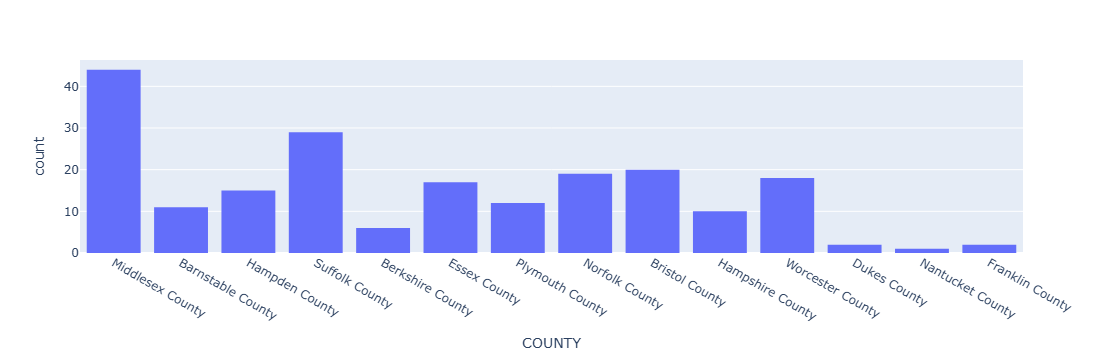

In [320]:


fig = px.histogram(patients, x="COUNTY")
fig.show()

Todas las pacientes son del Estado de Massachussets. 

In [323]:
#Edad de las pacientes
patients['BIRTHDATE'] = pd.to_datetime(patients['BIRTHDATE'])
ref_date = datetime(2024,1,1)
patients['AGE'] = (ref_date - patients['BIRTHDATE']).dt.days // 365

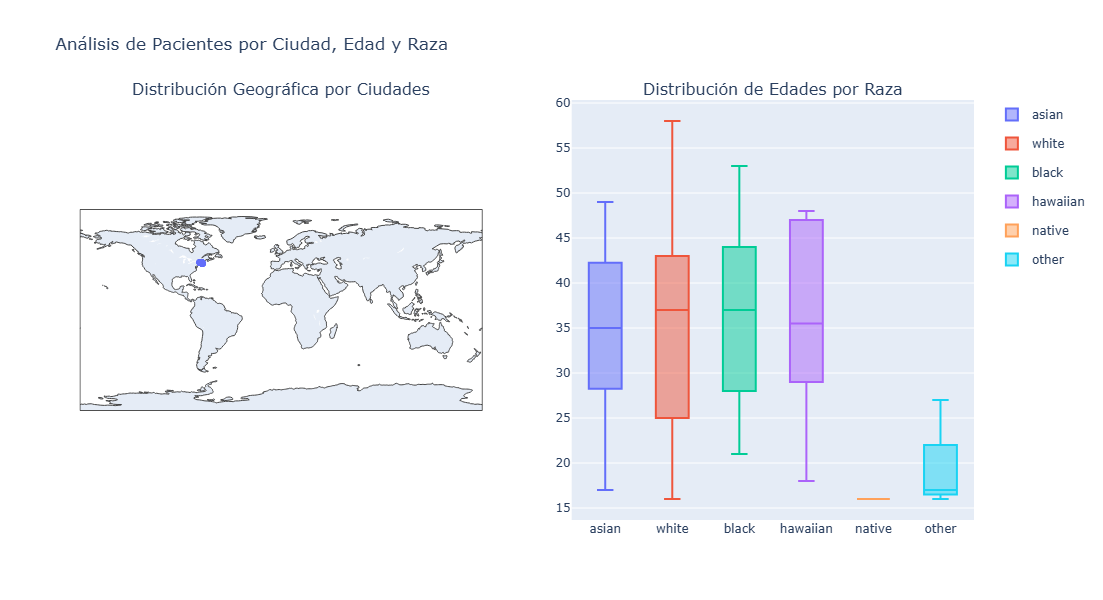

In [325]:
import plotly.subplots as sp
fig = sp.make_subplots(
    rows=1, cols=2,
    subplot_titles=("Distribución Geográfica por Ciudades", "Distribución de Edades por Raza"),
    specs=[[{"type": "geo"}, {"type": "xy"}]]  # Define el tipo de celda: geo y xy
)
geo_traces = px.scatter_geo(
    patients, 
    lat="LAT", 
    lon="LON", 
    hover_name="COUNTY",
    title="Distribución de las pacientes",
    projection = "natural earth"
).data
for trace in geo_traces:
    fig.add_trace(trace, row=1, col=1)
age_race_traces = px.box(
    patients, 
    x="RACE", 
    y = "AGE",
    color = "RACE",
    title= "Edad y raza de las pacientes"
).data
for trace in age_race_traces:
    fig.add_trace(trace, row=1, col=2)
fig.update_layout(height=600, width=1000, title_text="Análisis de Pacientes por Ciudad, Edad y Raza")
fig.show()

In [335]:
encountersFiltered.to_csv('encountersFiltered.csv', index=False)

In [339]:
patients.to_csv('patientsFiltered.csv', index=False)